# SynthItaly — clustering as a validation methodology

**Question.** Can off-the-shelf clustering, run on the synthetic transaction stream,
*recover the behaviours the model was built to encode* — the debtor archetypes
(climber / chronic / subsister) and the saving archetypes? If it can, the dataset is a
defensible teaching/validation artifact; where it *can't*, that is itself an honest finding.

> **Read this first — the circularity caveat.** The behaviours here are generated
> *deterministically from latent labels* (a chronic debtor *mechanically* runs an overdraft;
> a subsister *mechanically* draws on a credit line). So "recovering the labels" is partly
> circular. We therefore split every feature into **fair** behavioural signals (ordinary
> spending, bills, balance dynamics) and **`LEAK_`** debt-mechanic proxies, and we always
> report which set was used. This notebook is descriptive validation, **not** a claim about
> real-world predictability — see `prediction.ipynb` for the supervised counterpart and
> `../docs/WALKTHROUGH.md` for how the data is generated.

**What we do**
1. Engineer one feature row per consumer from the two exported tables.
2. **Study A** — partitional (KMeans) + hierarchical (Ward) clustering of the *whole
   population*, scored against the ground-truth archetypes (ARI / NMI / silhouette / PCA).
3. **Study A2** — the same, *within the debtor subpopulation*, where the three subtypes live.
4. **Study B** — clustering the per-consumer *accounts* to see what groups emerge.

## 1 · Setup & data generation

In [1]:
import math
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from synthitaly import numbers
from synthitaly.model import ItalyModel

warnings.filterwarnings("ignore")
pd.set_option("display.width", 120)
RNG_SEED = 42

# A long horizon (720 days ~ 24 months) so climbers can dig out of debt and the
# three debtor trajectories fully separate; 800 consumers so every archetype is
# populated. This is the same model the rest of the repo ships -- nothing here
# touches the simulation, we only ANALYSE its output.
model = ItalyModel(n_consumers=800, n_merchants_per_category=3, n_days=720, seed=RNG_SEED)
model.run()

df_tx = pd.DataFrame(model.transactions)
df_tx["date"] = pd.to_datetime(df_tx["date"])
df_acc = pd.DataFrame(model.export_accounts())
print("transactions:", df_tx.shape, "| accounts:", df_acc.shape)
df_tx.head(3)

transactions: (381350, 7) | accounts: (2400, 17)


,date,kind,from,to,category,amount_eur,macro_area
0,2017-01-01,purchase,856,6,retail,13.89,CENTRE
1,2017-01-01,purchase,447,40,clothing,25.12,CENTRE
2,2017-01-01,bill,297,98,rent,440.00,CENTRE


## 2 · Feature engineering (one row per consumer)

In [2]:
# Feature engineering: one row per CONSUMER, derived from the two exported tables
# (transactions + accounts). This used to be defined inline here and copy-pasted into
# prediction.ipynb, the tests and the figure script; the four copies drifted apart, which
# is why the numbers quoted in this notebook, in the figure captions and in the pinned
# tests all disagreed. There is now one implementation: synthitaly.features.
#
#   FAIR   columns are signals a bank could see from ordinary activity.
#   LEAK_  columns are debt-mechanic proxies that *mechanically* encode the label
#          (overdraft fees, credit draws, debt-service lines, savings/pension balances).
#
# Keeping them apart is what makes the honest "fair" analysis below possible.
from synthitaly import features as F

feats = F.build_features(model)
labels = F.label_frame(model)
data = feats.merge(labels, on="consumer_id")

FEAT_COLS = F.feature_columns(feats)
LEAK_COLS = F.leak_columns(feats)
FAIR_COLS = F.fair_columns(feats)
MONEY_COLS = F.money_columns(FEAT_COLS)
print(f"{len(FAIR_COLS)} fair features + {len(LEAK_COLS)} leakage features; {feats.isna().sum().sum()} NaNs")
data["debtor_subtype"].value_counts()

35 fair features + 10 leakage features; 0 NaNs


debtor_subtype
none         643
climber       83
chronic       38
subsister     36
Name: count, dtype: int64

In [3]:
from sklearn.preprocessing import StandardScaler  # used directly in Study B below

# log1p the heavy-tailed money columns, then z-score every column.
design_matrix = F.design_matrix

## 2b · Is the feature matrix factorable?

Study A below runs PCA and KMeans over this frame. Both assume the correlation matrix carries
**common** structure worth extracting — so test that rather than assume it, with the three
standard instruments: **Bartlett's** test of sphericity (is R distinguishable from the identity
at all?), the **Kaiser-Meyer-Olkin** measure of sampling adequacy (is the shared correlation
common, or merely pairwise?), and the **eigenvalue spectrum** (how many components clear the
Kaiser criterion of eigenvalue > 1). Implementation: `synthitaly.diagnostics`.

In [4]:
from synthitaly import diagnostics as D

# Can the full fair set even be inverted? KMO needs inv(R), and reaching for pinv on a
# singular matrix silently returns a confident number computed from floating-point noise --
# so diagnostics.kmo refuses instead.
R_full = D.correlation_matrix(feats, FAIR_COLS)
print(f"full fair set : {len(FAIR_COLS)} vars | rank {np.linalg.matrix_rank(R_full)} "
      f"| condition {np.linalg.cond(R_full):.2e}")
try:
    D.kmo(R_full)
except D.SingularMatrixError as exc:
    print(f"KMO refused   : {exc}")

shares = [c for c in FAIR_COLS if c.startswith(D.COMPOSITIONAL_PREFIX)]
row_sums = feats[shares].sum(axis=1)
print(f"\ncause         : the {len(shares)} share_* columns are proportions of one total and sum to "
      f"{row_sums.min():.6f}-{row_sums.max():.6f}\n                for every consumer -- an exact "
      f"linear dependency, so R loses a rank and cannot be inverted.")
print(f"compounded by : log(total_spend) = log(mean_ticket) + log(n_purchases) in log space, "
      f"and\n                total_income vs cur_total_in at r="
      f"{np.corrcoef(np.log1p(feats['total_income']), np.log1p(feats['cur_total_in']))[0, 1]:.4f}")


full fair set : 35 vars | rank 34 | condition 4.87e+17
KMO refused   : correlation matrix is singular (rank 34 of 35, reciprocal condition 2.05e-18). KMO needs inv(R); pseudo-inverting here would return a number computed from numerical noise. Reduce the column set first — see factorable_columns().

cause         : the 10 share_* columns are proportions of one total and sum to 1.000000-1.000000
                for every consumer -- an exact linear dependency, so R loses a rank and cannot be inverted.
compounded by : log(total_spend) = log(mean_ticket) + log(n_purchases) in log space, and
                total_income vs cur_total_in at r=0.9997


In [5]:
# Three reductions. B is the headline: dropping compositional shares is principled (they need
# a log-ratio transform before entering a factor model, not raw inclusion), as is dropping
# aggregates reconstructible from columns that stay. C is reported as a SENSITIVITY BOUND only --
# it prunes variables *because* their MSA was low, which raises KMO by construction.
B_COLS = D.factorable_columns(FAIR_COLS)
TREATMENTS = {
    "A · drop 1 share + duplicate aggregates":
        [c for c in FAIR_COLS if c not in D.DUPLICATE_AGGREGATES and c != shares[-1]],
    "B · drop all shares + duplicates  ← headline": B_COLS,
    "C · also drop low-MSA  (circular — bound only)":
        [c for c in B_COLS if c not in ("n_income", "bill_mortgage_n", "bill_rent_n")],
}

rows = []
for name, cols in TREATMENTS.items():
    R = D.correlation_matrix(feats, cols)
    overall, msa = D.kmo(R)
    chi2_stat, df, p = D.bartlett_sphericity(R, len(feats))
    spec = D.eigen_spectrum(R)
    rows.append({
        "treatment": name, "vars": len(cols),
        "KMO": round(overall, 3), "verdict": D.kmo_verdict(overall),
        "Bartlett χ²": round(chi2_stat), "df": df, "p": p,
        "eig>1": int(spec["kaiser"].sum()),
        "cum.var%": round(spec.loc[spec["kaiser"], "pct_variance"].sum(), 1),
    })
display(pd.DataFrame(rows).set_index("treatment"))

R_B = D.correlation_matrix(feats, B_COLS)
kmo_B, msa_B = D.kmo(R_B)
spec_B = D.eigen_spectrum(R_B)
msa_s = pd.Series(msa_B, index=B_COLS).sort_values()
print(f"headline (B): KMO = {kmo_B:.4f} → Kaiser verdict '{D.kmo_verdict(kmo_B)}'")
print(f"\nper-variable MSA — worst 4:\n{msa_s.head(4).round(3).to_string()}")
print(f"\nper-variable MSA — best 4:\n{msa_s.tail(4).round(3).to_string()}")
print("\neigenvalues (headline set):")
display(spec_B.head(12).round(3))


,vars,KMO,verdict,Bartlett χ²,df,p,eig>1,cum.var%
treatment,,,,,,,,
A · drop 1 share + duplicate aggregates,29,0.587,miserable,18451,406,0.0,11,76.3
B · drop all shares + duplicates ← headline,20,0.715,middling,14497,190,0.0,7,78.1
C · also drop low-MSA (circular — bound only),17,0.802,meritorious,12870,136,0.0,5,77.1


headline (B): KMO = 0.7153 → Kaiser verdict 'middling'

per-variable MSA — worst 4:
n_income            0.066
bill_mortgage_n     0.162
bill_utilities_n    0.199
bill_telecom_n      0.220

per-variable MSA — best 4:
weekday_concentration    0.855
n_purchases              0.858
late_fee_n               0.868
post_payday_share        0.873

eigenvalues (headline set):


,eigenvalue,pct_variance,cum_pct_variance,kaiser
component,,,,
1,7.701,38.504,38.504,True
2,1.920,9.599,48.103,True
3,1.543,7.715,55.818,True
4,1.259,6.293,62.111,True
5,1.130,5.648,67.759,True
6,1.068,5.342,73.101,True
7,1.009,5.043,78.144,True
8,0.966,4.832,82.976,False
9,0.825,4.126,87.103,False


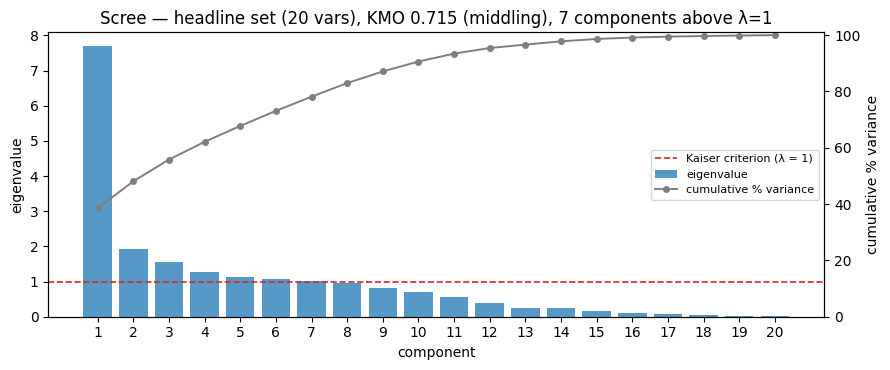

In [6]:
# Scree plot: eigenvalue per component with the Kaiser line at 1.0, plus cumulative variance.
fig, ax = plt.subplots(figsize=(9, 3.8))
x = spec_B.index
ax.bar(x, spec_B["eigenvalue"], color="tab:blue", alpha=0.75, label="eigenvalue")
ax.axhline(1.0, color="tab:red", ls="--", lw=1.2, label="Kaiser criterion (λ = 1)")
ax.set_xlabel("component"); ax.set_ylabel("eigenvalue"); ax.set_xticks(x)
ax.set_title(f"Scree — headline set ({len(B_COLS)} vars), "
             f"KMO {kmo_B:.3f} ({D.kmo_verdict(kmo_B)}), "
             f"{int(spec_B['kaiser'].sum())} components above λ=1")
ax2 = ax.twinx()
ax2.plot(x, spec_B["cum_pct_variance"], "o-", color="tab:grey", ms=4, lw=1.4,
         label="cumulative % variance")
ax2.set_ylabel("cumulative % variance"); ax2.set_ylim(0, 101)
h1, l1 = ax.get_legend_handles_labels(); h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2, fontsize=8, loc="center right")
fig.tight_layout(); plt.show()


**Reading 2b.** Bartlett rejects sphericity overwhelmingly in every treatment (χ² ≈ 14,500 on
190 df, p ≈ 0), so the features are emphatically correlated — there *is* structure. The question
KMO answers is whether that structure is **common-factor shaped**, and the answer is only
partly. The headline set reaches **KMO ≈ 0.715**, Kaiser's "middling": usable, not comfortable.

Three things are worth taking from this:

1. **The full 35-column set is not factorable at all.** It is singular by construction, because
   the `share_*` block is compositional. That is not a numerical nuisance to work around — it
   means any PCA/factor output over the raw share columns is partly reading a constraint rather
   than a behaviour. The shares would need a log-ratio transform to be admitted honestly.
2. **The eigenvalue spectrum is dominated by one component** (λ₁ ≈ 7.70, ~39% of variance in the
   headline set) with a long shallow tail — the income/spend scale axis that Study A also
   surfaces first. Seven components clear λ = 1 and together carry ~78%.
3. **KMO rises as variables are removed, and that is partly circular.** Treatment C reaches
   0.802 ("meritorious") only by dropping the variables whose MSA was worst, which inflates the
   statistic by construction. It is a sensitivity bound, not a result — the honest figure to
   quote is B's 0.715.

Consistent with `docs/EXPLANATION.md` §8a: a generator whose latent labels are *drawn* rather
than *caused* produces exactly this signature — real correlation, weak common-factor structure.

## 3 · Study A — clustering the whole population

Partitional **KMeans** swept over *k*, the model order chosen by the **silhouette** score
(and cross-checked with the elbow / inertia curve), exactly the recipe used in the prior
`moneyviz-baseline` work. We score each clustering against the true `debtor_subtype` with the
**Adjusted Rand Index** (ARI: 0 = chance, 1 = perfect).

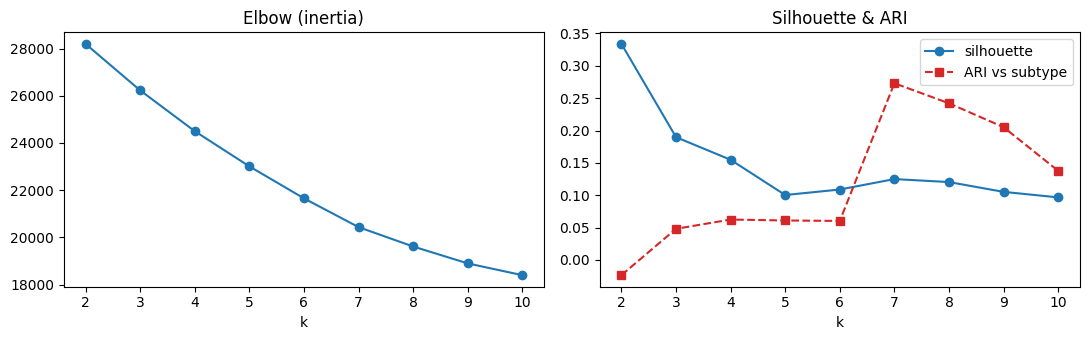

,inertia,silhouette,ARI_subtype
k,,,
2,28198.001,0.334,-0.024
3,26228.444,0.190,0.048
4,24500.226,0.155,0.062
5,23008.842,0.100,0.061
6,21654.037,0.109,0.060
7,20434.768,0.125,0.273
8,19613.152,0.120,0.242
9,18897.021,0.105,0.205
10,18398.584,0.097,0.138


In [7]:
from sklearn.cluster import KMeans
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

Xall = design_matrix(data, FEAT_COLS)
ks = range(2, 11)
rows = []
for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xall)
    rows.append({"k": k, "inertia": km.inertia_,
                 "silhouette": silhouette_score(Xall, km.labels_),
                 "ARI_subtype": adjusted_rand_score(data["debtor_subtype"], km.labels_)})
sweep = pd.DataFrame(rows).set_index("k")

fig, ax = plt.subplots(1, 2, figsize=(11, 3.5))
ax[0].plot(sweep.index, sweep["inertia"], "o-"); ax[0].set_title("Elbow (inertia)"); ax[0].set_xlabel("k")
ax[1].plot(sweep.index, sweep["silhouette"], "o-", label="silhouette")
ax[1].plot(sweep.index, sweep["ARI_subtype"], "s--", color="tab:red", label="ARI vs subtype")
ax[1].set_title("Silhouette & ARI"); ax[1].set_xlabel("k"); ax[1].legend()
fig.tight_layout(); plt.show()
sweep.round(3)

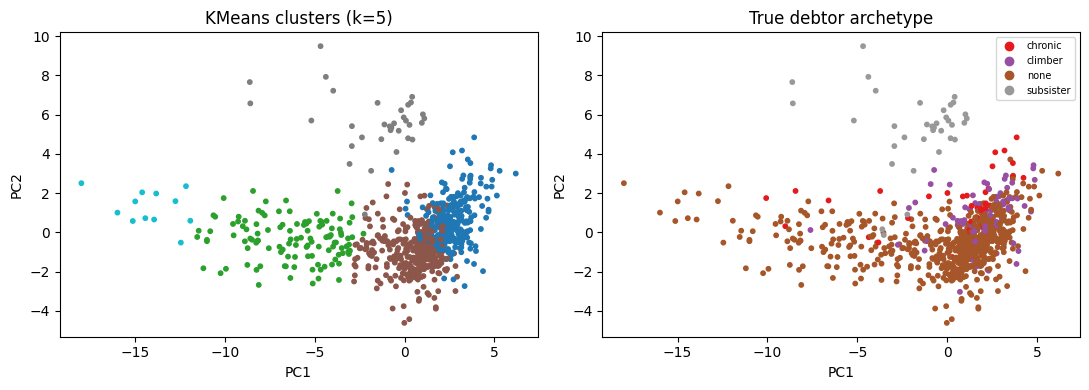

ARI vs debtor_subtype : 0.061
ARI vs income_source  : 0.061
NMI vs debtor_subtype : 0.2


In [8]:
# Fit at k=5 and look at the structure via PCA(2): colour by cluster vs by true archetype.
from sklearn.decomposition import PCA

km5 = KMeans(n_clusters=5, n_init=10, random_state=0).fit(Xall)
coords = PCA(n_components=2, random_state=0).fit_transform(Xall)
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].scatter(coords[:, 0], coords[:, 1], c=km5.labels_, cmap="tab10", s=10)
ax[0].set_title("KMeans clusters (k=5)")
codes = data["debtor_subtype"].astype("category")
sc = ax[1].scatter(coords[:, 0], coords[:, 1], c=codes.cat.codes, cmap="Set1", s=10)
ax[1].set_title("True debtor archetype")
ax[1].legend(handles=sc.legend_elements()[0], labels=list(codes.cat.categories), fontsize=7)
for a in ax: a.set_xlabel("PC1"); a.set_ylabel("PC2")
fig.tight_layout(); plt.show()

print("ARI vs debtor_subtype :", round(adjusted_rand_score(data["debtor_subtype"], km5.labels_), 3))
print("ARI vs income_source  :", round(adjusted_rand_score(data["income_source"], km5.labels_), 3))
print("NMI vs debtor_subtype :", round(normalized_mutual_info_score(data["debtor_subtype"], km5.labels_), 3))

**Reading Study A.** The dominant axis of variation is the **income / spending gradient**, not
debt status — debtors are only ~20% of the population, scattered *along* that gradient rather
than forming their own island. So whole-population clustering returns a low ARI against
`debtor_subtype`: the data does **not** spontaneously hand you the debtor archetypes. That is
the honest answer to "does clustering lead to the defined behaviours?" for the naive setup —
and it motivates the two refinements below.

## 4 · Study A2 — clustering *within* the debtor subpopulation

The three debtor subtypes only exist among debtors, so we cluster just them (k=3) and read the
confusion against the true subtype — with the full feature set (incl. `LEAK_` debt mechanics)
and with fair features only.

In [9]:
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram, linkage

deb = data[data["is_debtor"]].reset_index(drop=True)
print(f"{len(deb)} debtors:", deb["debtor_subtype"].value_counts().to_dict())

for tag, cols in [("ALL features", FEAT_COLS), ("FAIR only", FAIR_COLS)]:
    Xd = design_matrix(deb, cols)
    km = KMeans(n_clusters=3, n_init=10, random_state=0).fit(Xd)
    ward = AgglomerativeClustering(n_clusters=3, linkage="ward").fit(Xd)
    print(f"\n[{tag}]  KMeans ARI={adjusted_rand_score(deb['debtor_subtype'], km.labels_):.3f}"
          f"  Ward ARI={adjusted_rand_score(deb['debtor_subtype'], ward.labels_):.3f}"
          f"  silhouette={silhouette_score(Xd, km.labels_):.3f}")
    print(pd.crosstab(deb["debtor_subtype"], km.labels_, rownames=["true"], colnames=["cluster"]))

157 debtors: {'climber': 83, 'chronic': 38, 'subsister': 36}

[ALL features]  KMeans ARI=0.471  Ward ARI=0.419  silhouette=0.212
cluster     0   1  2
true                
chronic    29   1  8
climber    77   5  1
subsister   0  34  2



[FAIR only]  KMeans ARI=0.200  Ward ARI=0.068  silhouette=0.164
cluster    0   1   2
true                
chronic    5  26   7
climber    1  73   9
subsister  3  13  20


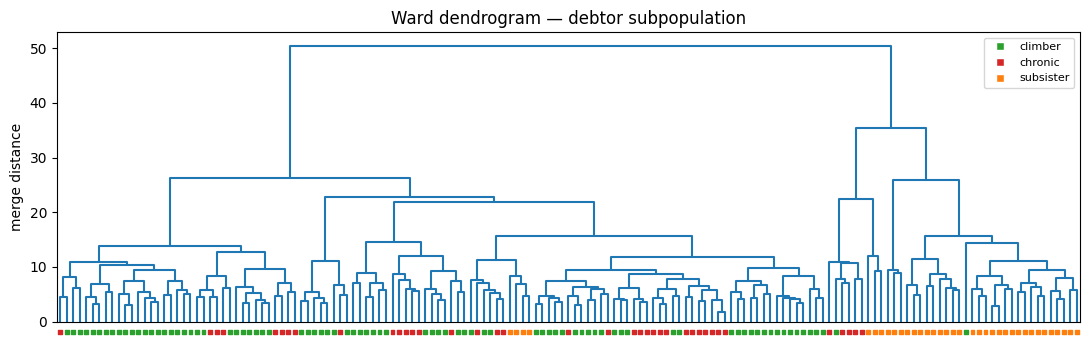

In [10]:
# Hierarchical view: a Ward dendrogram of the debtor subpopulation (ALL features).
Xd = design_matrix(deb, FEAT_COLS)
Z = linkage(Xd, method="ward")
fig, ax = plt.subplots(figsize=(11, 3.5))
palette = {"climber": "tab:green", "chronic": "tab:red", "subsister": "tab:orange"}
dendrogram(Z, no_labels=True, color_threshold=0.0, ax=ax)
ax.set_title("Ward dendrogram — debtor subpopulation")
ax.set_ylabel("merge distance")
# strip of true labels under the leaves
order = dendrogram(Z, no_plot=True)["leaves"]
ax.scatter(np.arange(len(order)) * 10 + 5, np.full(len(order), -2),
           c=[palette[deb["debtor_subtype"].iloc[i]] for i in order], s=8, marker="s", clip_on=False)
handles = [plt.Line2D([0], [0], marker="s", color="w", markerfacecolor=v, label=k) for k, v in palette.items()]
ax.legend(handles=handles, loc="upper right", fontsize=8)
fig.tight_layout(); plt.show()

**Reading Study A2.** With the debt-mechanic features the clusters line up with the true
subtypes (**KMeans ARI = 0.471**, Ward 0.419): the **subsister** group separates almost
perfectly — only subsisters draw on a credit line, and 34 of 36 land in one cluster — while
climber/chronic are the hard pair, with 77 climbers and 29 chronics sharing cluster 0. With
**fair features only** the ARI drops to **0.200** (Ward 0.068) and the confusion matrix
smears: the subtype distinction is largely *defined by mechanics we removed*, so unsupervised
clustering can only partly see it. That is the key methodological point: clustering validates
**separability**, but recovering a mechanically defined label needs supervision
(`prediction.ipynb`).

> **Why the recovery is one-sided — a finding, not a tuning failure.**
> `numbers.sample_debtor_subtype(rng, financially_vulnerable)` *draws* the subtype from a
> random tilt on a single binary flag. Conditional on vulnerability the label is close to
> noise: it is not *caused* by anything a fair behavioural feature can observe. Whatever
> separability survives comes from the divergent repayment rules acting *after* assignment,
> which is exactly why subsisters — who have a distinct mechanic, the credit draw — separate
> cleanly, while climbers and chronics, who differ only in repayment speed, do not. No amount
> of feature engineering or model tuning fixes this; the ceiling is a property of how the
> population is generated.

## 5 · Study B — clustering the accounts per consumer

Now the unit is the consumer's **account portfolio**: the current / savings / pension balances
and their activity. This asks a different question — what *financial-posture* groups emerge?

In [11]:
piv = df_acc.pivot_table(index="consumer_id", columns="account_type",
                         values=["balance", "n_entries", "total_in", "total_out"], fill_value=0.0)
piv.columns = [f"{a}_{b}" for a, b in piv.columns]
piv = piv.reset_index().merge(labels, on="consumer_id")
ACC_COLS = [c for c in piv.columns if any(c.startswith(p) for p in
            ("balance_", "n_entries_", "total_in_", "total_out_"))]
ACC_MONEY = [c for c in ACC_COLS if "balance" in c or "total" in c]

Xa = piv[ACC_COLS].copy()
for m in ACC_MONEY:
    Xa[m] = np.log1p(Xa[m].clip(lower=0))
Xa = StandardScaler().fit_transform(Xa)

rows = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, n_init=10, random_state=0).fit(Xa)
    rows.append({"k": k, "silhouette": silhouette_score(Xa, km.labels_),
                 "ARI_saver": adjusted_rand_score(piv["is_saver"], km.labels_),
                 "ARI_debtor": adjusted_rand_score(piv["is_debtor"], km.labels_),
                 "ARI_level": adjusted_rand_score(piv["income_level"], km.labels_)})
pd.DataFrame(rows).set_index("k").round(3)

,silhouette,ARI_saver,ARI_debtor,ARI_level
k,,,,
2,0.421,0.256,-0.004,-0.039
3,0.541,0.688,0.028,-0.007
4,0.562,0.484,0.007,0.157
5,0.562,0.461,0.010,0.149
6,0.512,0.398,0.009,0.119
7,0.475,0.363,0.004,0.122


,n,current,savings,pension,saver_rate,debtor_rate
cluster,,,,,,
0,277,18400.0,0.0,0.0,0.0,0.0
1,135,-12.0,350.0,276.0,0.0,0.0
2,218,1350.0,0.0,33650.0,1.0,0.0
3,170,855.0,25513.0,0.0,1.0,0.0


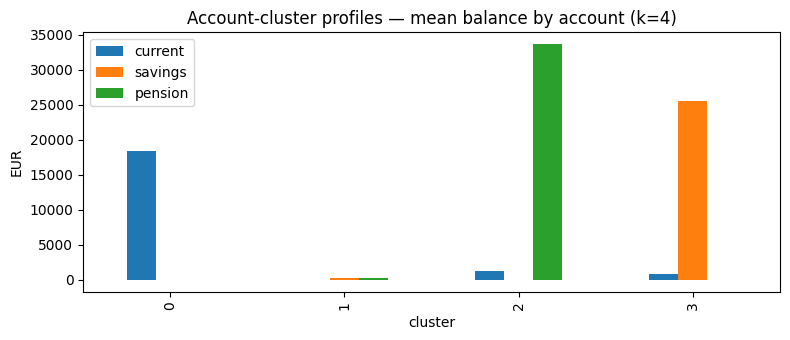

In [12]:
# k=4 profile: mean balance in each account, plus saver / debtor rates -> name the groups.
km4 = KMeans(n_clusters=4, n_init=10, random_state=0).fit(Xa)
piv["cluster"] = km4.labels_
profile = piv.groupby("cluster").agg(
    n=("consumer_id", "size"),
    current=("balance_current", "mean"),
    savings=("balance_savings", "mean"),
    pension=("balance_pension", "mean"),
    saver_rate=("is_saver", "mean"),
    debtor_rate=("is_debtor", "mean"),
).round(0)
display(profile)

fig, ax = plt.subplots(figsize=(8, 3.5))
profile[["current", "savings", "pension"]].plot.bar(ax=ax)
ax.set_title("Account-cluster profiles — mean balance by account (k=4)")
ax.set_ylabel("EUR"); ax.set_xlabel("cluster")
fig.tight_layout(); plt.show()

**Reading Study B.** Account clustering cleanly recovers the **saving** archetypes (ARI vs
`is_saver` ≈ 0.6–0.7), not the debt ones — the emergent groups are *pension-funded savers*,
*ordinary-savings savers*, *cash-hoarding non-savers* (a large current balance and nothing
swept out — the high-income / self-employed pattern flagged in `WALKTHROUGH.md`), and
*hand-to-mouth* (everything near zero). The accounts encode how people *save*, so that is what
clusters out.

## 5b · Study C — clustering for **saver / non-saver**

Study A2 asked whether clustering recovers the *debtor* archetypes (it partly does, ARI
0.47). This asks the same question of the other label. It also exposes something the
debtor work could not: **"fair" is a property of a (feature, label) pair, not of a
feature.**

`FAIR_COLS` quarantines what mechanically encodes *debtor* status. Two of its columns —
`cur_total_out` and `cur_balance` — encode *saver* status almost completely, because
`Consumer._month_close` sweeps the month's positive residual into savings or pension and
that sweep is a **debit on the current account**. `synthitaly.features.saver_fair_columns()`
removes them; `fair_columns()` is left alone so every debtor number above is unchanged.

In [ ]:
# Study C — does unsupervised clustering find savers? Two targets, two feature sets.
SAVER_FAIR_COLS = F.saver_fair_columns(feats)
print(f"saver-fair: {len(SAVER_FAIR_COLS)} cols "
      f"= fair ({len(FAIR_COLS)}) minus {list(F.LEAK_SAVER)}")
print("class balance:", data["is_saver"].value_counts().to_dict())

rows, preds = [], {}
for tag, cols in (("naive", FEAT_COLS), ("saver-fair", SAVER_FAIR_COLS)):
    X = design_matrix(data, cols)
    for k, target in ((2, "is_saver"), (4, "financial_status")):
        lab_ = KMeans(n_clusters=k, n_init=10, random_state=0).fit_predict(X)
        preds[(tag, k)] = (X, lab_)
        rows.append({"features": tag, "n": len(cols), "k": k, "target": target,
                     "ARI": adjusted_rand_score(data[target], lab_),
                     "NMI": normalized_mutual_info_score(data[target], lab_),
                     "silhouette": silhouette_score(X, lab_)})
saver_clus = pd.DataFrame(rows)
display(saver_clus.round(4))

# k=2 on the saver-fair set: is the split anything like the saver split?
X2, lab2 = preds[("saver-fair", 2)]
print("\nk=2 clusters vs true saver status (saver-fair features):")
print(pd.crosstab(data["is_saver"], lab2, rownames=["is_saver"], colnames=["cluster"]))

# PCA(2): colour by cluster vs by the true label. If saver status were a dominant axis
# the two panels would look alike. They do not — that is the finding.
coords = PCA(n_components=2, random_state=0).fit_transform(X2)
fig, ax = plt.subplots(1, 2, figsize=(11, 4), sharex=True, sharey=True)
ax[0].scatter(coords[:, 0], coords[:, 1], c=lab2, cmap="tab10", s=10)
ax[0].set_title("KMeans clusters (k=2)")
ax[1].scatter(coords[:, 0], coords[:, 1],
              c=data["is_saver"].map({True: "tab:green", False: "tab:grey"}), s=10)
ax[1].set_title("True saver status (green = saver)")
for a in ax:
    a.set_xlabel("PC1"); a.set_ylabel("PC2")
fig.tight_layout(); plt.show()


**Reading Study C.** Clustering **does not** recover saver status — ARI ≈ 0.008 at k = 2,
and barely better against the four-way `financial_status`. The `naive` row is the telling
one: even with the label mechanically present in the features — where `prediction.ipynb`
§4b scores **0.9999** — clustering still cannot find it.

Saver status is a real but **low-variance** direction in this feature space. KMeans
partitions on the dominant axes (income scale, activity volume), and the saver split is
not one of them; the healthy silhouette (≈ 0.38) confirms it found *a* clean structure,
just not this one. The PCA panels show it directly: the cluster boundary cuts across the
saver colouring rather than along it.

Put beside Study A2 (debtor ARI 0.47), the pair gives the transferable lesson:
**clustering recovers a label only when that label aligns with a dominant axis of
variation; prediction only needs the signal to be present at all.**

## 6 · Validation verdict

All figures below are **measured** at the pinned configuration (800 consumers x 720 days,
seed 42) by the cells above — not estimates. The full 45-column feature frame comes from
`synthitaly.features`.

| Setup | Recovers | ARI (measured) |
|---|---|---|
| Whole-population behavioural clustering (k=5) | the income/spend gradient, **not** debtor subtypes | **0.061** (best over k: 0.273 at k=7) |
| Debtor-subpopulation, **all** features | climber / chronic / subsister (subsister near-perfect) | **0.471** (Ward 0.419) |
| Debtor-subpopulation, **fair** features | little — subtypes are mechanically defined | **0.200** (Ward 0.068) |
| Account clustering (k=3) | the saving archetypes | **0.688** vs `is_saver` |

**So: does the data allow these analyses, and do they lead to the defined behaviours?** Yes —
*with the right pairing of method, feature set, and subpopulation*. Unsupervised structure is
real and interpretable, but it surfaces the **dominant** axis (income / saving) first; the
debtor archetypes are recoverable once you either restrict to debtors (with the mechanic
features) or switch to supervision. A good student exercise is exactly this: discover that the
naive clustering "fails", and work out *why* (class imbalance + a mechanically-defined target).

**A leak that hid in plain sight.** One column, `cur_n_entries` — a raw count of
current-account entries — was classified *fair* until it was audited. It silently includes the
debt-service, credit-draw and overdraft lines, so it re-imported the very leak the `LEAK_`
prefix exists to quarantine. Regressed on the other fair activity counts (`n_purchases`,
`n_bills`, `n_income`; R² = 0.975), its residual correlates **+0.46** with the debt-mechanic
line count and predicts `is_debtor` alone at **AUC 0.78**; mean residual by subtype runs
none −2.8, climber +10.8, subsister +6.0, chronic +18.5, tracking the extra entries the debt
machinery actually writes. On its own it moved the headline fair AUC in `prediction.ipynb`
from **0.91 to 0.70**. It is now `LEAK_cur_n_entries`. The lesson generalises: a feature is
not fair because its *name* is innocuous — it is fair only if the generating process cannot
write the label into it.

*Caveat repeated:* every recovery above is partly circular because the behaviours are generated
from the labels. The honest payoff is **separability** (the archetypes are distinguishable in
the data) plus the negative results (what clustering can and cannot see), not a claim about the
real world.